A: [1. 1. 1. 1.]
B: [4. 4. 4. 4.]
C: [1. 1. 1. 1.]
D: [-12.  12. -12.  12.]
M: [ 0.         -4.36363636  5.45454545 -5.45454545  4.36363636  0.        ]


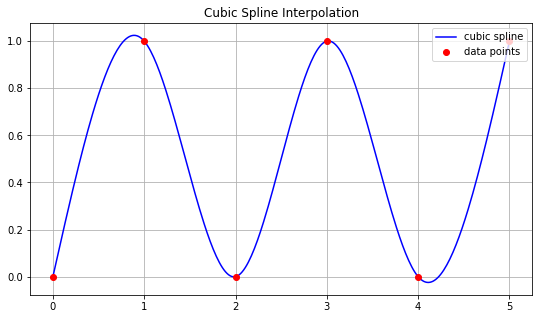

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# data points
x = np.array([0, 1, 2, 3, 4, 5], dtype = float)
y = np.array([0, 1, 0, 1, 0, 1], dtype = float)
n = len(x)
h = np.diff(x)  # step sizes

# set up the tridiagonal matrix for the interior points
size = n - 2
A = np.zeros(size)  # sub-diagonal
B = np.zeros(size)  # main diagonal
C = np.zeros(size)  # super-diagonal
D = np.zeros(size)  # right hand side

for k in range(size):
    i = k + 1
    A[k] = h[i - 1]
    B[k] = 2 * (h[i - 1] + h[i])
    C[k] = h[i]
    D[k] = 6 * ((y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1])

print("A:", A)
print("B:", B)
print("C:", C)
print("D:", D)

# thomas algorithm to solve the tridiagonal system
b = B.copy()
d = D.copy()
for i in range(1, size):
    w = A[i - 1] / b[i - 1]
    b[i] = b[i] - w * C[i - 1]
    d[i] = d[i] - w * d[i - 1]

M_interior = np.zeros(size)
M_interior[-1] = d[-1] / b[-1]
for i in range(size - 2, -1, -1):
    M_interior[i] = (d[i] - C[i] * M_interior[i + 1]) / b[i]

# natural spline so endpoints are 0
M = np.zeros(n)
M[1:-1] = M_interior
print("M:", M)


def evaluate_spline(t, x, y, h, M):
    # Evaluate the cubic spline at a given point t.
    n = len(x)
    # find which interval we're in
    i = np.searchsorted(x, t, side='right') - 1
    i = int(np.clip(i, 0, n - 2))

    dx = t - x[i]
    a_i = y[i]
    b_i = (y[i + 1] - y[i]) / h[i] - h[i] * (2 * M[i] + M[i + 1]) / 6
    c_i = M[i] / 2
    d_i = (M[i + 1] - M[i]) / (6 * h[i])

    return a_i + b_i * dx + c_i * dx**2 + d_i * dx**3


# evaluate the spline at a bunch of points for plotting
x_eval = np.linspace(x[0], x[-1], 300)
y_eval = np.array([evaluate_spline(t, x, y, h, M) for t in x_eval])

# plotting
plt.figure(figsize=(9, 5))
plt.plot(x_eval, y_eval, 'b-', label='cubic spline')
plt.plot(x, y, 'ro', label='data points')
plt.legend()
plt.grid(True)
plt.title('Cubic Spline Interpolation')
plt.show()